----

In [ ]:
# Copyright 2024 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Intro to Building a Scalable and Modular RAG System with RAG Engine in Vertex AI

<table align="left">
  <td style="text-align: center">
    <a href="https://colab.research.google.com/github/GoogleCloudPlatform/generative-ai/blob/main/gemini/rag-engine/intro_rag_engine.ipynb">
      <img width="32px" src="https://www.gstatic.com/pantheon/images/bigquery/welcome_page/colab-logo.svg" alt="Google Colaboratory logo"><br> Open in Colab
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https:%2F%2Fraw.githubusercontent.com%2FGoogleCloudPlatform%2Fgenerative-ai%2Fmain%2Fgemini%2Frag-engine%2Fintro_rag_engine.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Google Cloud Colab Enterprise logo"><br> Open in Colab Enterprise
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/workbench/deploy-notebook?download_url=https://raw.githubusercontent.com/GoogleCloudPlatform/generative-ai/main/gemini/rag-engine/intro_rag_engine.ipynb">
      <img src="https://www.gstatic.com/images/branding/gcpiconscolors/vertexai/v1/32px.svg" alt="Vertex AI logo"><br> Open in Vertex AI Workbench
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/rag-engine/intro_rag_engine.ipynb">
      <img width="32px" src="https://www.svgrepo.com/download/217753/github.svg" alt="GitHub logo"><br> View on GitHub
    </a>
  </td>
</table>

<div style="clear: both;"></div>

<b>Share to:</b>

<a href="https://www.linkedin.com/sharing/share-offsite/?url=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/rag-engine/intro_rag_engine.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/8/81/LinkedIn_icon.svg" alt="LinkedIn logo">
</a>

<a href="https://bsky.app/intent/compose?text=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/rag-engine/intro_rag_engine.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/7/7a/Bluesky_Logo.svg" alt="Bluesky logo">
</a>

<a href="https://twitter.com/intent/tweet?url=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/rag-engine/intro_rag_engine.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/5/5a/X_icon_2.svg" alt="X logo">
</a>

<a href="https://reddit.com/submit?url=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/rag-engine/intro_rag_engine.ipynb" target="_blank">
  <img width="20px" src="https://redditinc.com/hubfs/Reddit%20Inc/Brand/Reddit_Logo.png" alt="Reddit logo">
</a>

<a href="https://www.facebook.com/sharer/sharer.php?u=https%3A//github.com/GoogleCloudPlatform/generative-ai/blob/main/gemini/rag-engine/intro_rag_engine.ipynb" target="_blank">
  <img width="20px" src="https://upload.wikimedia.org/wikipedia/commons/5/51/Facebook_f_logo_%282019%29.svg" alt="Facebook logo">
</a>            

| Author |
| --- |
| [Holt Skinner](https://github.com/holtskinner) |

---

## Overview

Retrieval Augmented Generation (RAG) improves Large Language Models (LLMs) by allowing them to access and process external information sources during generation. This ensures the model's responses are grounded in factual data and avoids hallucinations.

A common problem with LLMs is that they don't understand private knowledge, that
is, your organization's data. With RAG Engine, you can enrich the
LLM context with additional private information, because the model can reduce
hallucinations and answer questions more accurately.

By combining additional knowledge sources with the existing knowledge that LLMs
have, a better context is provided. The improved context along with the query
enhances the quality of the LLM's response.

The following image illustrates the key concepts to understanding Vertex AI RAG Engine. <br>

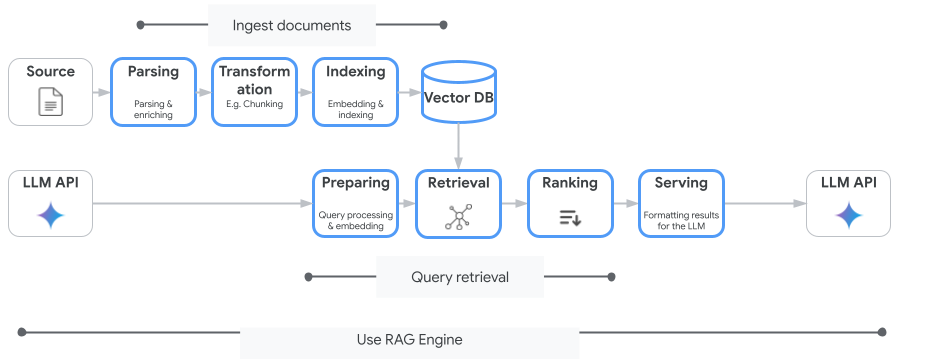 <br>

The following concepts are key to understanding Vertex AI RAG Engine. These concepts are listed in the order of the
retrieval-augmented generation (RAG) process.

1. **Data ingestion**: Intake data from different data sources. For example,
  local files, Google Cloud Storage, and Google Drive.

1. **Data transformation**: Conversion of the data in preparation for indexing. For example, data is split into chunks.

1. **Embedding**: Numerical representations of words or pieces of text. These numbers capture the
   semantic meaning and context of the text. Similar or related words or text
   tend to have similar embeddings, which means they are closer together in the
   high-dimensional vector space.

1. **Data indexing**: RAG Engine creates an index called a corpus.
   The index structures the knowledge base so it's optimized for searching. For
   example, the index is like a detailed table of contents for a massive
   reference book.

1. **Retrieval**: When a user asks a question or provides a prompt, the retrieval
  component in RAG Engine searches through its knowledge
  base to find information that is relevant to the query.

1. **Generation**: The retrieved information becomes the context added to the
  original user query as a guide for the generative AI model to generate
  factually grounded and relevant responses.

For more information, refer to the public documentation for [Vertex AI RAG Engine](https://cloud.google.com/vertex-ai/generative-ai/docs/rag-overview).

---

## Get started

### Install Vertex AI SDK and Google Gen AI SDK


In [ ]:
%pip install --upgrade --quiet google-cloud-aiplatform google-genai

### Authenticate your notebook environment (Colab only)

If you're running this notebook on Google Colab, run the cell below to authenticate your environment.

In [ ]:
import sys

if "google.colab" in sys.modules:
    from google.colab import auth

    auth.authenticate_user()

---

### Set Google Cloud project information and initialize Vertex AI SDK

To get started using Vertex AI, you must have an existing Google Cloud project and [enable the Vertex AI API](https://console.cloud.google.com/flows/enableapi?apiid=aiplatform.googleapis.com).

Learn more about [setting up a project and a development environment](https://cloud.google.com/vertex-ai/docs/start/cloud-environment).

See [supported regions](https://cloud.google.com/vertex-ai/generative-ai/docs/rag-engine/rag-overview#supported-regions) for location options.


In [ ]:
# Use the environment variable if the user doesn't provide Project ID.
import os

import vertexai
from google import genai

# fmt: off
PROJECT_ID = "[your-project-id]"  # @param {type: "string", placeholder: "[your-project-id]", isTemplate: true}
# fmt: on
if not PROJECT_ID or PROJECT_ID == "[your-project-id]":
    PROJECT_ID = str(os.environ.get("GOOGLE_CLOUD_PROJECT"))

# See https://cloud.google.com/vertex-ai/generative-ai/docs/rag-engine/rag-overview#supported-regions for location options.
vertexai.init(project=PROJECT_ID, location="us-east4")
client = genai.Client(vertexai=True, project=PROJECT_ID, location="global")

### Import libraries

In [ ]:
from IPython.display import Markdown, display
from google.genai.types import GenerateContentConfig, Retrieval, Tool, VertexRagStore
from vertexai import rag

### Create a RAG Corpus

In [ ]:
# Currently supports Google first-party embedding models
# fmt: off
EMBEDDING_MODEL = "publishers/google/models/text-embedding-005"  # @param {type:"string", isTemplate: true}
# fmt: on

rag_corpus = rag.create_corpus(
    display_name="my-rag-corpus",
    backend_config=rag.RagVectorDbConfig(
        rag_embedding_model_config=rag.RagEmbeddingModelConfig(
            vertex_prediction_endpoint=rag.VertexPredictionEndpoint(
                publisher_model=EMBEDDING_MODEL
            )
        )
    ),
)

### Check the corpus just created

In [ ]:
rag.list_corpora()

### Upload a local file to the corpus

In [ ]:
%%writefile test.md

Retrieval-Augmented Generation (RAG) is a technique that enhances the capabilities of large language models (LLMs) by allowing them to access and incorporate external data sources when generating responses. Here's a breakdown:

**What it is:**

* **Combining Retrieval and Generation:**
    * RAG combines the strengths of information retrieval systems (like search engines) with the generative power of LLMs.
    * It enables LLMs to go beyond their pre-trained data and access up-to-date and specific information.
* **How it works:**
    * When a user asks a question, the RAG system first retrieves relevant information from external data sources (e.g., databases, documents, web pages).
    * This retrieved information is then provided to the LLM as additional context.
    * The LLM uses this augmented context to generate a more accurate and informative response.

**Why it's helpful:**

* **Access to Up-to-Date Information:**
    * LLMs are trained on static datasets, so their knowledge can become outdated. RAG allows them to access real-time or frequently updated information.
* **Improved Accuracy and Factual Grounding:**
    * RAG reduces the risk of LLM "hallucinations" (generating false or misleading information) by grounding responses in verified external data.
* **Enhanced Contextual Relevance:**
    * By providing relevant context, RAG enables LLMs to generate more precise and tailored responses to specific queries.
* **Increased Trust and Transparency:**
    * RAG can provide source citations, allowing users to verify the information and increasing trust in the LLM's responses.
* **Cost Efficiency:**
    * Rather than constantly retraining large language models, RAG allows for the introduction of new data in a more cost effective way.

In essence, RAG bridges the gap between the vast knowledge of LLMs and the need for accurate, current, and contextually relevant information.


In [ ]:
rag_file = rag.upload_file(
    corpus_name=rag_corpus.name,
    path="test.md",
    display_name="test.md",
    description="my test file",
)

### Import files from Google Cloud Storage

Remember to grant "Viewer" access to the "Vertex RAG Data Service Agent" (with the format of `service-{project_number}@gcp-sa-vertex-rag.iam.gserviceaccount.com`) for your Google Cloud Storage bucket.

For this example, we'll use a public GCS bucket containing earning reports from Alphabet.

In [ ]:
INPUT_GCS_BUCKET = (
    "gs://cloud-samples-data/gen-app-builder/search/alphabet-investor-pdfs/"
)

response = rag.import_files(
    corpus_name=rag_corpus.name,
    paths=[INPUT_GCS_BUCKET],
    # Optional
    transformation_config=rag.TransformationConfig(
        chunking_config=rag.ChunkingConfig(chunk_size=1024, chunk_overlap=100)
    ),
    max_embedding_requests_per_min=900,  # Optional
)

### Import files from Google Drive

Eligible paths can be formatted as:

- `https://drive.google.com/drive/folders/{folder_id}`
- `https://drive.google.com/file/d/{file_id}`.

Remember to grant "Viewer" access to the "Vertex RAG Data Service Agent" (with the format of `service-{project_number}@gcp-sa-vertex-rag.iam.gserviceaccount.com`) for your Drive folder/files.


In [ ]:
response = rag.import_files(
    corpus_name=rag_corpus.name,
    paths=["https://drive.google.com/drive/folders/{folder_id}"],
    # Optional
    transformation_config=rag.TransformationConfig(
        chunking_config=rag.ChunkingConfig(chunk_size=512, chunk_overlap=50)
    ),
)

### Optional: Perform direct context retrieval

In [ ]:
# Direct context retrieval
response = rag.retrieval_query(
    rag_resources=[
        rag.RagResource(
            rag_corpus=rag_corpus.name,
            # Optional: supply IDs from `rag.list_files()`.
            # rag_file_ids=["rag-file-1", "rag-file-2", ...],
        )
    ],
    rag_retrieval_config=rag.RagRetrievalConfig(
        top_k=10,  # Optional
        filter=rag.Filter(
            vector_distance_threshold=0.5,  # Optional
        ),
    ),
    text="What is RAG and why it is helpful?",
)
print(response)

# Optional: The retrieved context can be passed to any SDK or model generation API to generate final results.
# context = " ".join([context.text for context in response.contexts.contexts]).replace("\n", "")

### Create RAG Retrieval Tool

In [ ]:
# Create a tool for the RAG Corpus
rag_retrieval_tool = Tool(
    retrieval=Retrieval(
        vertex_rag_store=VertexRagStore(
            rag_corpora=[rag_corpus.name],
            similarity_top_k=10,
            vector_distance_threshold=0.5,
        )
    )
)

### Generate Content with Gemini using RAG Retrieval Tool

In [ ]:
MODEL_ID = "gemini-2.0-flash-001"

In [ ]:
response = client.models.generate_content(
    model=MODEL_ID,
    contents="What is RAG?",
    config=GenerateContentConfig(tools=[rag_retrieval_tool]),
)

display(Markdown(response.text))

### Generate Content with Llama3 using RAG Retrieval Tool

In [ ]:
from vertexai import generative_models

# Load tool into Llama model
rag_retrieval_tool = generative_models.Tool.from_retrieval(
    retrieval=rag.Retrieval(
        source=rag.VertexRagStore(
            rag_resources=[rag.RagResource(rag_corpus=rag_corpus.name)],
            rag_retrieval_config=rag.RagRetrievalConfig(
                top_k=10,  # Optional
                filter=rag.Filter(
                    vector_distance_threshold=0.5,  # Optional
                ),
            ),
        ),
    )
)

llama_model = generative_models.GenerativeModel(
    # your self-deployed endpoint for Llama3
    "projects/{project}/locations/{location}/endpoints/{endpoint_resource_id}",
    tools=[rag_retrieval_tool],
)

In [ ]:
response = llama_model.generate_content("What is RAG?")

display(Markdown(response.text))

---